add all three ingredients which were all discussed separately. 
1. Do not assume small angle approximation , thus do not expand $\sin \theta$
2. include friction of the form $-q(d\theta/dt)$
3. Add sinusoidal driving force $F_{D}\sin(\Omega_{D}t)$
putting all of these ingredients together, we have the equation of motion 
$$\frac{d^{2}\theta}{dt^{2}}=\frac{g}{l}\sin \theta-q \frac{d\theta}{dt}+F_{D}\sin(\Omega_{D}t)$$

Rewriting equation above as two first-order differential equations and obtain 
$$\begin{lgathered}
\frac{d\omega}{dt}=-\frac{g}{l}\sin \theta-q \frac{d\theta}{dt}+F_{D}\sin(\Omega_{D}t) \\
\frac{d\theta}{dt}=\omega
\end{lgathered}$$
Converted into difference equation for $\theta_{i}$ and $\omega _i$
$$\begin{lgathered}
\omega_{i+1}=\omega_{i}+\left[ -\frac{g}{l}\sin \theta-q\omega_{i}+F_{D}\sin(\Omega_{D}t_{i}) \right]\Delta t\\ \theta_{i+1}=\theta_{i}+\omega_{i+1}\Delta t
\end{lgathered}$$

In [50]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

In [51]:
dt = 0.1
g = 9.8 
l = 1


t = np.arange(0, 60+dt, dt) 
omega = np.zeros(len(t))
theta = np.zeros(len(t))

theta[0] = 0.2

m = -4.5
if m > 3.14 : 
    m -= 3.14 

if m < -3.14: 
    m += 2*3.14
m

1.7800000000000002

In [52]:
def PhysicalPendulum (dt, g, l, theta0, q, FD, omegaD) :
    # creating a range for time from 0 to 150+dt
    t = np.arange(0, 150+dt, dt) 
    # creating a range of angular velocity (omega) and angular displacement (theta) with all zeroes and have length = time range (
    # note to self: try to use 2 dimensional arrays next time
    omega = np.zeros(len(t))
    theta = np.zeros(len(t))      
    # setting the initial angular displacement
    theta[0] = theta0

    # Euler Cromer method
    for i in range(len(t)-1): 
        omega[i+1] = omega[i] - ((g/l)*np.sin(theta[i]) + q*omega[i] - FD*np.sin(omegaD*t[i]))*dt
        theta[i+1] = theta[i] + dt*omega[i+1]

        # if angular displacement < pi, + 2pi
        if theta[i+1] < -3.14: 
            theta[i+1]+=2*3.14

        #if angular displacent > pi, -2pi
        if theta[i+1] > 3.14:
            theta[i+1]-=2*3.14
        
        t[i+1] = t[i] + dt

    return t, theta, omega


t_chaotic, theta_chaotic, omega_chaotic = PhysicalPendulum(0.04,g,9.8, 0.2,0.5,1.2,2/3)
t_noFD, theta_noFD, omega_noFD = PhysicalPendulum(0.04,g,9.8,0.2,0.5,0,2/3)
t_smallFD, theta_smallFD, omega_smallFD = PhysicalPendulum(0.04,g,9.8,0.2,0.5,0.5,2/3)

<function matplotlib.pyplot.show(close=None, block=None)>

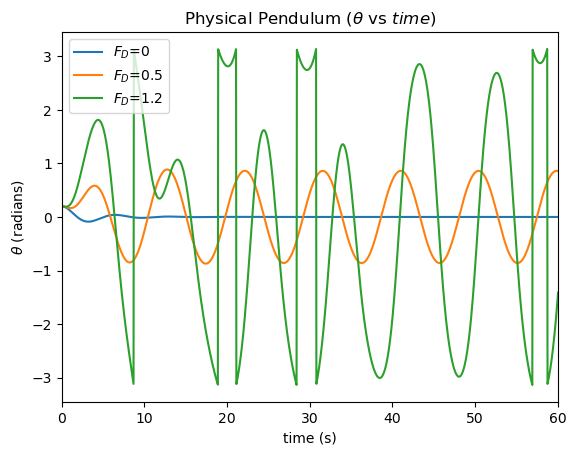

In [53]:
plt.plot(t_noFD, theta_noFD, label = r'$F_D$=0')
plt.plot(t_smallFD, theta_smallFD, label = r'$F_D$=0.5')
plt.plot(t_chaotic, theta_chaotic, label = r'$F_D$=1.2')


plt.xlabel('time (s)') 
plt.ylabel(r"$\theta$ (radians)") 
plt.title(r"Physical Pendulum ($\theta$ vs $time$)") 
plt.legend()
plt.xlim(0,60)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

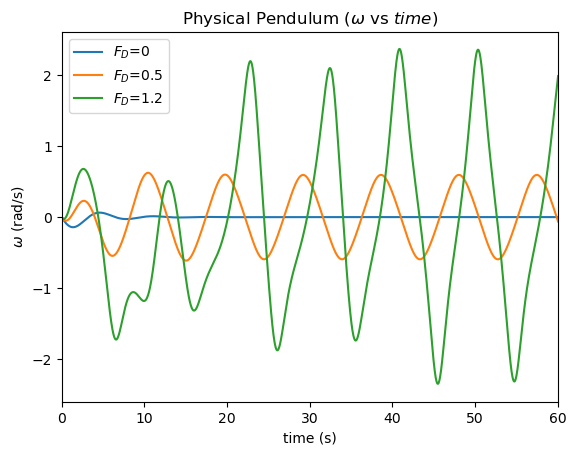

In [54]:
plt.plot(t_noFD, omega_noFD, label = r'$F_D$=0')
plt.plot(t_smallFD, omega_smallFD, label = r'$F_D$=0.5')
plt.plot(t_chaotic, omega_chaotic, label = r'$F_D$=1.2')


plt.xlabel('time (s)') 
plt.ylabel(r"$\omega$ (rad/s)") 
plt.title(r"Physical Pendulum ($\omega$ vs $time$)") 
plt.legend()
plt.xlim(0,60)
plt.show


C:\Users\aisya\AppData\Local\Temp\ipykernel_16160\3904184655.py:5: RuntimeWarning: divide by zero encountered in log
  delta_theta_F05 = np.log(abs(theta1_F05-theta2_F05))


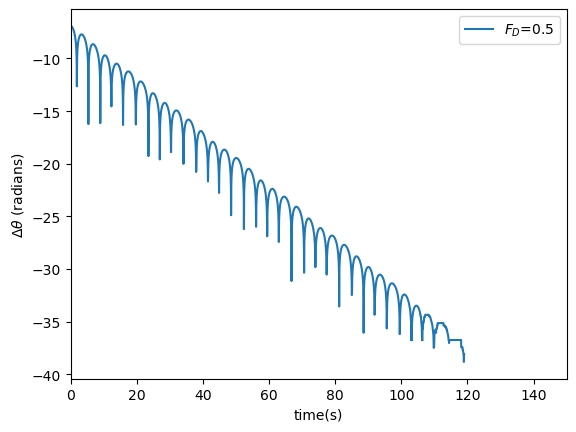

In [55]:
# Physical pendulum with driving force of 0.5 (non-chaotic) with slightly different initial angle
t1_F05, theta1_F05, omega1_F05 = PhysicalPendulum(0.04,g,9.8, 0.2   ,0.5, 0.5 ,0.666667)
t2_F05, theta2_F05, omega2_F05_F05 = PhysicalPendulum(0.04,g,9.8, 0.201 ,0.5, 0.5 ,0.666667)

delta_theta_F05 = np.log(abs(theta1_F05-theta2_F05))

plt.plot(t1_F05, delta_theta_F05, label = r"$F_{D}$=0.5")
plt.xlim(0,150)
plt.ylabel(r"$\Delta \theta$ (radians)")
plt.xlabel("time(s)")
plt.legend()
plt.show()

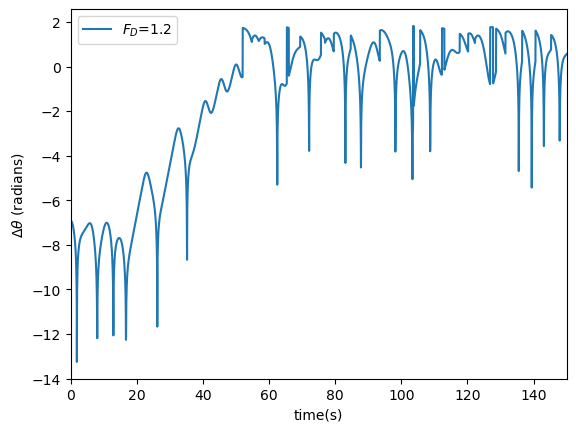

In [56]:
# two Physical pendulum with driving force of 1.2 (chaotic) with slightly different initial angle
t1_F12, theta1_F12, omega1_F12 = PhysicalPendulum(0.04,g,9.8, 0.2   ,0.5, 1.2 ,0.666667)
t2_F12, theta2_F12, omega2_F12 = PhysicalPendulum(0.04,g,9.8, 0.201 ,0.5, 1.2 ,0.666667)

delta_theta_F12 = np.log(abs(theta1_F12-theta2_F12))

plt.plot(t1_F12, delta_theta_F12, label = r"$F_{D}$=1.2")
plt.xlim(0,150)
plt.ylabel(r"$\Delta \theta$ (radians)")
plt.xlabel("time(s)")
plt.legend()
plt.show()

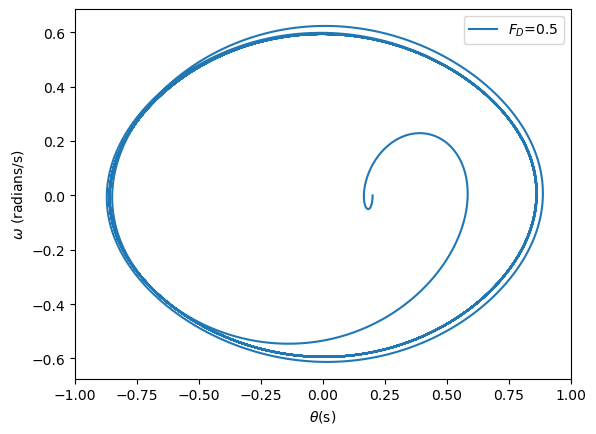

In [57]:

plt.plot(theta1_F05,  omega1_F05, label = r"$F_{D}$=0.5")
plt.xlim(-1,1)
plt.ylabel(r"$\omega$ (radians/s)")
plt.xlabel(r"$\theta$(s)")
plt.legend()
plt.show()

In [58]:
theta1_F12

array([ 0.2       ,  0.19968213,  0.19910444, ..., -2.63088981,
       -2.66206762, -2.69289965], shape=(3751,))

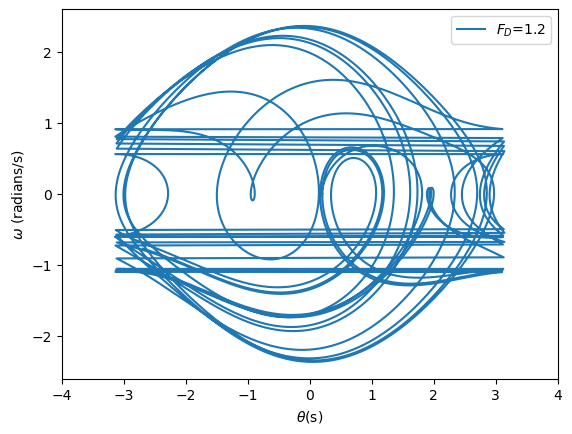

In [59]:

plt.plot(theta1_F12,  omega1_F12, label = r"$F_{D}$=1.2")
plt.xlim(-4,4)
plt.ylabel(r"$\omega$ (radians/s)")
plt.xlabel(r"$\theta$(s)")
plt.legend()
plt.show()

## Poincare Section 
plotted points only at times that were in phase with the drive force, that is at times $t \approx 2\pi n/\omega_D$

## Poincare Example from [StackOverFlow](https://stackoverflow.com/questions/70301658/drawing-poincare-section-using-python)

In [64]:
def PoincarePhysicalPendulum (tf, dt, g, l, theta0, q, FD, omegaD) :
    
    num_plotpoints = int(tf/dt) 

    # creating a range of angular velocity (omega) and angular displacement (theta) with all zeroes and have length = number of plot points
    # note to self: try to use 2 dimensional arrays next time
    omega = np.zeros(num_plotpoints)
    theta = np.zeros(num_plotpoints)   
    time = np.zeros (num_plotpoints) 
    
    # setting the initial angular displacement
    theta[0] = theta0
    omega[0] = 0

    poincare_theta, poincare_omega = [], []

    # Driving period
    T = 2*np.pi/omegaD

    for i in range (num_plotpoints-1): 
        time[i+1] = time[i] + dt 
    
        # Euler Cromer method
        omega[i+1] = omega[i] - ((g/l)*np.sin(theta[i]) + q*omega[i] - FD*np.sin(omegaD*time[i]))*(dt)
        theta[i+1] = theta[i] + omega[i+1]*dt
    
        # Keep theta within [-pi, pi]
        if theta[i+1] < -np.pi: 
            theta[i+1]+=2*np.pi
        elif theta[i+1] > np.pi:
            theta[i+1]-=2*np.pi

        # check if t is within dt/2 of a multiple of T
        if abs((time[i+1] % T)) < dt:
            poincare_theta.append(theta[i+1])
            poincare_omega.append(omega[i+1])

    return poincare_theta, poincare_omega
        
       
poincare_theta, poincare_omega = PoincarePhysicalPendulum (50000, 0.04,9.8,9.8, 0.2 ,0.5, 1.2 ,2/3)

<function matplotlib.pyplot.show(close=None, block=None)>

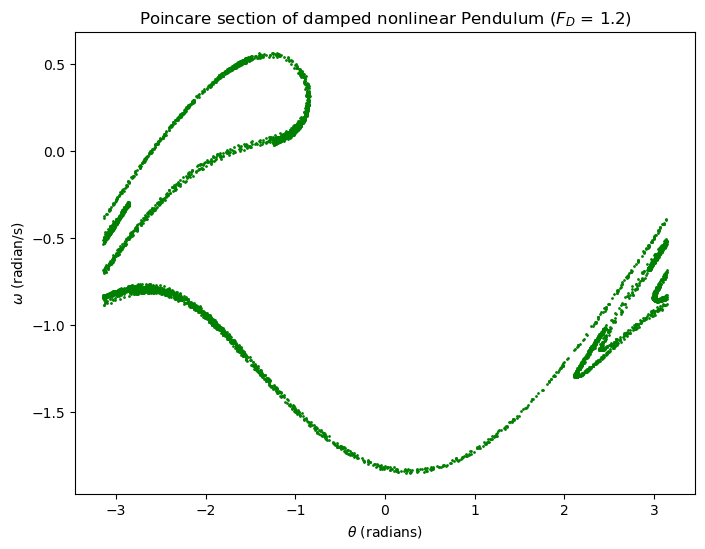

In [65]:
plt.figure(figsize=(8, 6))
plt.plot(poincare_theta[:], poincare_omega[:], 'o', color ='green', markersize=1) 

plt.title(r'Poincare section of damped nonlinear Pendulum ($F_D$ = 1.2)')
plt.ylabel(r"$\omega$ (radian/s)") 
plt.xlabel(r"$\theta$ (radians)") 

plt.show